# 💻 **Evidencia 2**

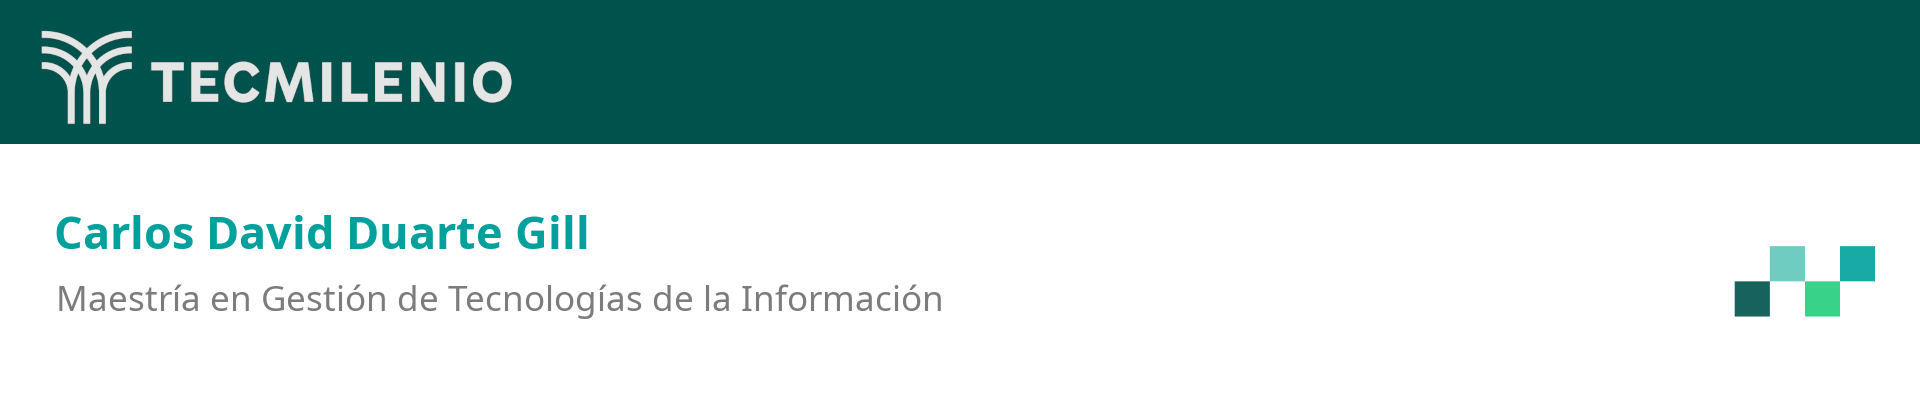

## **Análisis estadístico y exploratorio**

- Alumno: Carlos David Duarte Gill
- Matricula: 7089642
- Correo: AL07089642@tecmilenio.mx
- Profesor: Julio César Cruz Cruz
- Fecha:  lunes 06 de octubre de 2025

*Cursando la Maestría en Gestión de Tecnologías de la Información*

# 🔤 Introducción

## Contextualización del escenario
La presente **Evidencia 2** es una extensión de la Evidencia 1, y su objetivo es profundizar en la predicción de riesgos y la optimización de recursos en el sector de seguros de salud.

Recapitulando, en el análisis inicial se reveló que el dataset simulado no contine fuertes correlaciones lineales entre las variables clave: Age y Billing Amount, lo que significa que debemos cambiar de estrategia. Por lo que en esta segunda fase, en lugar de buscar relaciones lineales, nos centraremos en técnicas multivariadas y no lineales para descubrir patrones ocultos y segmentar a la población de pacientes.

## Alcance del análisis en la Evidencia 2

El alcance de la Evidencia 2 se define en tres pilares principales:

- Análisis multivariado avanzado
- Generación de insights estratégicos
- Reflexión ética y conclusiones

# 🩺 Revisión del análisis previo realizado en la Evidencia 1

Recordemos que nuestro dataset, después de un proceso de limpieza y transformación, cuenta con 18 columnas y 54,841 registros, lo que significa que tenemos suficiente volumen y dimensionalidad para aplicar PCA y K-means.


El dataset en cuestión incluye:

- Variables de gasto, tales como Billing Amount y Billing Amount (Normalized).
- Variables demográficas ó categoricas, tales como Age, Gender (Encoded), Medical Condition y Medical Condition (Encoded).
- Variable de eficiencia, tales como Duration of Stay (Days).

Sin embargo, para profundizar en el analisis, he decidio crear tres nuevas variables las cuales son descritas en el paso: [🆕 Nuevas columnas para análisis multivariado o de series temporales](https://colab.research.google.com/drive/1A_Y15NIhHjUeriAS7hhuZWdEmZXAJD7Q#scrollTo=98_f-5q36xeM&line=1&uniqifier=1)

# 📁 Carga el conjunto de datos en Python

Recordemos que este dataset ha sido editado con valores nulos aleatorios para efectos academicos de esta practica, asi mismo se han insertado registros duplicados aleatorios. El dataset con valores nulos y duplicados se encuentra en: https://raw.githubusercontent.com/RamRider89/analisis-estadistico-exploratorio/refs/heads/main/evidencia-1/healthcare_dataset.csv


**A continuación:**

🧰 Se importan las librerías necesarias para el análisis y la visualización como numpy, scipy.stats, matplotlib.pyplot y seaborn, entre otras.

🔧 Se carga el dataset y se muestra una tabla descriptiva del dataset.

## 🧰 Carga de todas las librerías necesarias

In [1]:
# cargando todas las librerías necesarias
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
# scales
from sklearn.preprocessing import MinMaxScaler
# labels categoricos
from sklearn.preprocessing import LabelEncoder

# pca
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# series temporales
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

# warnings
import warnings
warnings.filterwarnings('ignore')

print("Librerias importadas!")

Librerias importadas!


In [2]:
# estilo de las graficas
sns.set_style("white")
# colores tecmilenio
_color_tecmi_light="#26d07c"
_color_tecmi_dark="#00534c"
_color_teal="#20c997"
# colores generales
_color_purple="#6f42c1"
_color_pink="#e83e8c"
_color_orange="#fd7e14"
# colores boostrap
_color_primary="#007bff"
_color_success="#28a745"
_color_info="#17a2b8"
_color_warning="#ffc107"
# tamaños de fuente
_fontsize_title = 16
_fontsize_label = 12
_fontsize_marker = 9
# paletas de colores prearmadas
_paleta_tecmi = [_color_tecmi_light, _color_purple, _color_warning, _color_info, _color_primary]
_paleta_secundaria = [_color_tecmi_light, _color_primary, _color_purple]

## Carga del dataset desde URL pública

In [3]:
# definimos la url del archivo csv
_URL_ = 'https://raw.githubusercontent.com/RamRider89/analisis-estadistico-exploratorio/refs/heads/main/evidencia-1/healthcare_dataset.csv'

# definiendo los nombres de las columnas del archivo
_Name_ = 'Name'
_Age_ = 'Age'
_Gender_ = 'Gender'
_Blood_Type_ = 'Blood Type'
_Medical_Condition_ = 'Medical Condition'
_Date_Admission_ = 'Date of Admission'
_Doctor_ = 'Doctor'
_Hospital_ = 'Hospital'
_Insurance_Provider_ = 'Insurance Provider'
_Billing_Amount_ = 'Billing Amount'
_Room_Number_ = 'Room Number'
_Admission_Type_ = 'Admission Type'
_Discharge_Date_ = 'Discharge Date'
_Medication_ = 'Medication'
_Test_Results_ = 'Test Results'
_COLUMNAS_CSV_ = [_Name_, _Age_, _Gender_, _Blood_Type_, _Medical_Condition_, _Date_Admission_, _Doctor_, _Hospital_, _Insurance_Provider_, _Billing_Amount_, _Room_Number_, _Admission_Type_, _Discharge_Date_, _Medication_, _Test_Results_]

# leyendo el archivo csv mediante pandas
df = pd.read_csv(_URL_, usecols=_COLUMNAS_CSV_)

## 🔍 Información de la estructura del DataSet

In [4]:
# definición de columnas por su tipo de estructura
_COLUMNAS_NUMERICAS_ = [_Age_, _Billing_Amount_, _Room_Number_]
_COLUMNAS_CATEGORICAS_ = [_Gender_, _Blood_Type_, _Medical_Condition_, _Insurance_Provider_, _Admission_Type_, _Medication_, _Test_Results_]
_COLUMNAS_TEXTO_ = [_Name_, _Doctor_, _Hospital_]
_COLUMNAS_FECHA_ = [_Date_Admission_, _Discharge_Date_]

In [5]:
print("\033[1m --- Dataset cargado correctamente --- \033[0m")
print("-"*80)
print(f"Dataset shape: {df.shape}")
print(f"Número de filas: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}")

 --- Dataset cargado correctamente --- 
--------------------------------------------------------------------------------
Dataset shape: (55507, 15)
Número de filas: 55507
Número de columnas: 15


# 🩺 Diagnóstico y limpieza de registros mediante ETL

Se repite el proceso sistemático de ETL realizado en la Evidencia 1 para nuestro dataset, con el objetivo de limpieza y transformación de los datos.

### 🔡 Convertir las columnas de texto a minúsculas

Primeramente, se procede a convertir las variables tipo texto en minúsculas con el objetivo de asegurar la consistencia y uniformidad de los datos. De esta manera nos aseguramos de eliminar las variaciones en las cadenas de texto que podrían ser tratadas como registros únicos por algún algoritmo. Además, con esto aseguramos el encontrar y eliminar completamente los registros duplicados.

In [6]:
# en base a nuestras columnas de texto tales como _Name_, _Doctor_, _Hospital_
columnas_texto = df[_COLUMNAS_TEXTO_]

# recorremos las columnas para convertir sus valores a lowercase
for col in columnas_texto.columns:
    # asignación limpia de nuevos valores mediante loc
    df.loc[:, col] = df[col].str.lower()

## 🔴 Detección y eliminación de duplicados

Nuestro dataset **healthcare-dataset.csv** contiene registros duplicados que deben ser eliminados para evitar que sesguen el análisis.

In [7]:
print("\033[1m --- Limpieza de registros duplicados: --- \033[0m")
print("-" * 80)
print(f"Número de filas antes de la limpieza: {df.shape[0]}")
# contamos los registros duplicados
total_duplicados = df.duplicated().sum()
print(f"Registros \033[1m duplicados encontrados: {total_duplicados}\033[0m")
# eliminamos duplicados y nos aseguramos de que df_limpio sea una copia explícita
df_limpio = df.drop_duplicates().copy()
# resultados
print("-" * 80)
print(f"Número de \033[1m filas después de la limpieza: {df_limpio.shape[0]}\033[0m")
print(f"Número de columnas después de la limpieza: \033[1m {df_limpio.shape[1]}\033[0m")

 --- Limpieza de registros duplicados: --- 
--------------------------------------------------------------------------------
Número de filas antes de la limpieza: 55507
Registros  duplicados encontrados: 541
--------------------------------------------------------------------------------
Número de  filas después de la limpieza: 54966
Número de columnas después de la limpieza:  15


## 🔴 Eliminación de registros con Monto facturado negativo

🚨 Se ha detectado la presencia de valores negativos en la columna del monto facturado, la cuál es una anomalía significativa que definitivamente puede distorsionar nuestro análisis.

Los montos facturados negativos no tienen sentido en este contexto de servicios médicos y podrían deberse a errores en la entrada de datos.

Primeramente procederemos a calcular el número de registros negativos en el Dataset.

In [8]:
print("\033[1m --- Identificación de registros negativos --- \033[0m")
print("-" * 80)
# conteo
registros_negativos = df_limpio[df_limpio[_Billing_Amount_] < 0]
print(f"Registros con valores negativos: \033[1m {len(registros_negativos)} \033[0m")

 --- Identificación de registros negativos --- 
--------------------------------------------------------------------------------
Registros con valores negativos:  106 


🚨 Debido a que los valores negativos pueden ocacionar un sesgo en la media, la desviación estándar y el rango, además de afectar negativamente la precisión de las predicciones, he decidido optar por **eliminar los registros** que presenten este error.

Dado que tenemos 106 valores negativos en la columna Billing Amount, la mejor estrategia es eliminarlos. Este número es muy pequeño en comparación con el tamaño total de nuestro dataset, por lo que la eliminación no afectará significativamente la integridad del análisis.

In [9]:
print("\033[1m --- Eliminando registros negativos --- \033[0m")
print("-" * 80)
# eliminar las filas con valores negativos
df_limpio = df_limpio[df_limpio[_Billing_Amount_] >= 0]
# resultados
print(f"Número de \033[1m filas después de la limpieza: {df_limpio.shape[0]}\033[0m")
print(f"Número de columnas después de la limpieza: \033[1m {df_limpio.shape[1]}\033[0m")

 --- Eliminando registros negativos --- 
--------------------------------------------------------------------------------
Número de  filas después de la limpieza: 54841
Número de columnas después de la limpieza:  15


De esta manera podremos trabajar con un conjunto de datos más limpio y confiable, asegurando que los análisis y predicciones se basen únicamente en datos válidos y lógicos.

## 🔴 Detección y manejo de nulos

A continuación, identificaremos los valores nulos en el dataset y aplicaremos una estrategia de imputación para rellenar valores faltantes.

In [10]:
print("\033[1m --- Valores nulos por columna: --- \033[0m")
print("-" * 80)
# contamos todos los valores nulos de todas las columnas
nulos_por_columna = df_limpio.isnull().sum().reset_index()

# rajuste para mostrar los valores nulos como tabla
nulos_por_columna.columns=['Columna', 'Nulos']
print(nulos_por_columna.sort_values(by='Nulos', ascending=False))

 --- Valores nulos por columna: --- 
--------------------------------------------------------------------------------
               Columna  Nulos
1                  Age     22
2               Gender     16
3           Blood Type      6
4    Medical Condition      6
11      Admission Type      5
5    Date of Admission      0
0                 Name      0
6               Doctor      0
7             Hospital      0
9       Billing Amount      0
8   Insurance Provider      0
10         Room Number      0
12      Discharge Date      0
13          Medication      0
14        Test Results      0


A continuación, aplicaremos una imputación de valores utilizando la mediana para las columnas numéricas para evitar el sesgo de outliers.

Enseguida, aplicaremos una imputación en las columnas categóricas como 'Gender' y 'Medical Condition' con el valor más frecuente de estas variables.


### 🔢 Imputación de todas las columnas numericas

In [11]:
# imputando variables numéricas mediante el valor promedio
print("\033[1m --- Imputando variables numericas: --- \033[0m")
print("-" * 80)
# recorremos las columnas
for col in [_Age_, _Billing_Amount_]:
    # calculamos el valor promedio
    mediana = df_limpio[col].median()
    # rellenamos los valores nulos con la mediana, y utilizando .loc para una asignación segura
    df_limpio.loc[:, col] = df_limpio[col].fillna(mediana)
    # mensaje
    print(f"Inputando columna: \033[1m { col } \033[0m - con la mediana: \033[1m { str(mediana) } \033[0m")

 --- Imputando variables numericas: --- 
--------------------------------------------------------------------------------
Inputando columna:  Age  - con la mediana:  52.0 
Inputando columna:  Billing Amount  - con la mediana:  25590.7671438869 


### 🔡 Imputación de todas las columnas categóricas

In [12]:
# imputando variables categóricas mediante la moda
print("\033[1m --- Imputando variables categóricas: --- \033[0m")
print("-" * 80)
# recorremos las columnas
for col in [_Gender_, _Blood_Type_, _Medical_Condition_, _Admission_Type_ ]:
    # calculamos la moda de cada columna
    moda = df_limpio[col].mode()[0]
    # asignación segura mediante .loc
    df_limpio.loc[:, col] = df_limpio[col].fillna(moda)
    # mensaje a usuario
    print(f"Inputando columna: \033[1m { col } \033[0m - con el valor más frecuente: \033[1m { str(moda) } \033[0m ")

    # comprobacion
    #print(df_limpio.isnull().sum().loc[lambda x: x > 0].sort_values(ascending=False))

 --- Imputando variables categóricas: --- 
--------------------------------------------------------------------------------
Inputando columna:  Gender  - con el valor más frecuente:  Male  
Inputando columna:  Blood Type  - con el valor más frecuente:  A-  
Inputando columna:  Medical Condition  - con el valor más frecuente:  Arthritis  
Inputando columna:  Admission Type  - con el valor más frecuente:  Elective  


### ✅ Verificación de imputación



In [13]:
print("\033[1m --- Verificación de valores nulos por columna --- \033[0m")
print("-" * 80)
# contamos todos los valores nulos de todas las columnas
nulos_por_columna = df_limpio.isnull().sum().reset_index()
# rajuste para mostrar los valores nulos como tabla
nulos_por_columna.columns=['Columna', 'Nulos']
nulos_por_columna.sort_values(by='Nulos', ascending=False)

 --- Verificación de valores nulos por columna --- 
--------------------------------------------------------------------------------


,Columna,Nulos
0,Name,0
1,Age,0
2,Gender,0
3,Blood Type,0
4,Medical Condition,0
5,Date of Admission,0
6,Doctor,0
7,Hospital,0
8,Insurance Provider,0
9,Billing Amount,0


Se verifica que ya no contamos con ningún valor nulo.

### ✅ Verificación de valores únicos en columnas categóricas

In [14]:
# en base a nuestras columnas categoricas:_Gender_, _Blood_Type_, _Medical_Condition_, _Insurance_Provider_, _Admission_Type_, _Medication_, _Test_Results_
columnas_categoricas = df_limpio[_COLUMNAS_CATEGORICAS_]
# definimos el diccionario de valores unicos
_dict_unique_values_ = {
    _Gender_: [],
    _Blood_Type_: [],
    _Medical_Condition_: [],
    _Insurance_Provider_: [],
    _Admission_Type_: [],
    _Medication_: [],
    _Test_Results_: []
}

# recorremos las columnas categoricas para obtener sus valores
print("\033[1m --- Valores únicos por columna categórica: --- \033[0m")
print("-" * 80)
for col in columnas_categoricas.columns:
    # obtenemos los vals unicos
    unique_values = columnas_categoricas[col].unique()
    # asignamos los valores unicos al dict
    _dict_unique_values_[col] = columnas_categoricas[col].unique()

# para mostrar el resultado del diccionario en pantalla
# convertimos el diccionario a un conjunto de listas
data = [[key] + list(value) for key, value in _dict_unique_values_.items()]

# definimos los titulos de la tabla
headers = ["Columna"] + [f"Valor unico {i+1}" for i in range(len(max(_dict_unique_values_.values(), key=len)))]
print(tabulate(data, headers=headers, tablefmt="grid"))


 --- Valores únicos por columna categórica: --- 
--------------------------------------------------------------------------------
+--------------------+-----------------+-----------------+-----------------+------------------+-----------------+-----------------+-----------------+-----------------+
| Columna            | Valor unico 1   | Valor unico 2   | Valor unico 3   | Valor unico 4    | Valor unico 5   | Valor unico 6   | Valor unico 7   | Valor unico 8   |
+====================+=================+=================+=================+==================+=================+=================+=================+=================+
| Gender             | Male            | Female          |                 |                  |                 |                 |                 |                 |
+--------------------+-----------------+-----------------+-----------------+------------------+-----------------+-----------------+-----------------+-----------------+
| Blood Type         | B-     

De esta manera hemos comprobado los valores únicos de nuestras columnas categóricas, mismo que ya están limpios y sin valores nulos.

## ⚙️ Transformación y Normalización de Variables

A continuación, se procederá a transformar las variables para hacerlas útiles para el análisis y modelado.

### ✔ 1. Creación de una nueva variable: Duration of Stay

Se creará una nueva columna **Duration of Stay (Days)** la cual contendrá la duración en días de los pacientes dentro del hospital.

Para poder hacer este cálculo, las fechas de admisión y alta deben de ser convertidas a **datetime**.

#### Convirtiendo las fechas a datetime

In [15]:
# convirtiendo cada registro a datetime
# usamos .loc para realizar la conversión uno a uno
df_limpio.loc[:, _Date_Admission_] = pd.to_datetime(df_limpio.loc[:, _Date_Admission_], errors='coerce')
df_limpio.loc[:, _Discharge_Date_] = pd.to_datetime(df_limpio.loc[:, _Discharge_Date_], errors='coerce')
# convirtiendo el tipo de dato de la columna
df_limpio[_COLUMNAS_FECHA_] = df_limpio[_COLUMNAS_FECHA_].astype('datetime64[ns]')

#### Agregando nueva columna

In [16]:
# creando la nueva columna Duration of Stay (Days)
# esta nueva columna contendrá la duración en dias de los pacientes dentro del hospital
_Duration_Stay_ = 'Duration of Stay (Days)'

# calculando la duración de la estancia en días
df_limpio.loc[:, _Duration_Stay_] = (df_limpio.loc[:, _Discharge_Date_] - df_limpio.loc[:, _Date_Admission_]).dt.days

# verificando
print("\033[1m --- Verificando nueva columna --- \033[0m")
print("-" * 80)
_COLUMNAS_FECHA_ = [_Date_Admission_, _Discharge_Date_, _Duration_Stay_]
df_limpio[_COLUMNAS_FECHA_].dtypes

 --- Verificando nueva columna --- 
--------------------------------------------------------------------------------


Date of Admission          datetime64[ns]
Discharge Date             datetime64[ns]
Duration of Stay (Days)             int64
dtype: object

### ✔ 2. Normalización de la columna Billing Amount

La variable **Billing Amount** que corresponde al costo de atención médica, tiene un rango de valores muy amplio, lo que puede afectar negativamente a modelos de aprendizaje sensibles a la escala como K-Means.

La normalización (Min-Max) escalará los valores a un rango entre 0 y 1, lo que asegurará que todos los datos tengan el mismo peso en el análisis.

In [17]:
# se inicializa el escalador Min-Max
scaler = MinMaxScaler()
# definimos la nueva columna
_Billing_Amount_Normalized_ = 'Billing Amount (Normalized)'

# aplicamos la normalización a la columna
df_limpio.loc[:, _Billing_Amount_Normalized_] = scaler.fit_transform(df_limpio.loc[:,[_Billing_Amount_]])

### ✔ 3. Recodificación de Variables Categóricas

**Los** modelos de machine learning no pueden procesar variables categóricas como Gender y Medical Condition directamente, es por ello que realizaremos una recodificación automática a un formato numérico, lo cual es esencial para el modelado.

In [18]:
# inicializamos el codificador Label Encoding
le = LabelEncoder()

# nuevas columnas
_Gender_Encoded_ = 'Gender (Encoded)'
_Medical_Condition_Encoded_ = 'Medical Condition (Encoded)'

# aplicamos un label Encoding a la columna 'Gender'
df_limpio.loc[:, _Gender_Encoded_] = le.fit_transform(df_limpio.loc[:, _Gender_])

# aplicamos un label Encoding a la columna 'Medical Condition'
df_limpio.loc[:, _Medical_Condition_Encoded_] = le.fit_transform(df_limpio.loc[:, _Medical_Condition_])

# dict
_dict_unique_med_values_ = {
    _Medical_Condition_: df_limpio[_Medical_Condition_].unique(),
    _Medical_Condition_Encoded_: df_limpio[_Medical_Condition_Encoded_].unique()
}

# para mostrar el resultado del diccionario en pantalla
# convertimos el diccionario a un conjunto de listas
data = [[key] + list(value) for key, value in _dict_unique_med_values_.items()]

# definimos los titulos de la tabla
headers = ["Columna"] + [f"Valor unico {i+1}" for i in range(len(max(_dict_unique_med_values_.values(), key=len)))]

# imprimiendo
print("\033[1m --- Recodificación de Variables Categóricas --- \033[0m")
print("-" * 80)
print(tabulate(data, headers=headers, tablefmt="grid"))

 --- Recodificación de Variables Categóricas --- 
--------------------------------------------------------------------------------
+-----------------------------+-----------------+-----------------+-----------------+-----------------+-----------------+-----------------+
| Columna                     | Valor unico 1   | Valor unico 2   | Valor unico 3   | Valor unico 4   | Valor unico 5   | Valor unico 6   |
+=============================+=================+=================+=================+=================+=================+=================+
| Medical Condition           | Cancer          | Arthritis       | Obesity         | Diabetes        | Asthma          | Hypertension    |
+-----------------------------+-----------------+-----------------+-----------------+-----------------+-----------------+-----------------+
| Medical Condition (Encoded) | 2               | 0               | 5               | 3               | 1               | 4               |
+----------------------------

Al momento, se han realizado tres transformaciones:
1. **Creación de una nueva variable: Duration of Stay**
2. **Normalización de la columna Billing Amount**
3. **Recodificación de Variables Categóricas**

Además de la transformación inicial para **convertir todas las columas texto a lowercase.**

Con estas transformaciones, nuestro dataset está limpio y enriquecido.

# 🆕 Nuevas columnas para análisis multivariado o de series temporales

## Propuesta de nuevas columnas

Tome la decisión de añadir nuevas columnas que me ayuden en capturar la complejidad de la interacción del paciente con los gastos y las condiciones medicas. Esto será clave para mejorar el rendimiento de los modelos, especialmente después de que el modelo de regresión lineal simple fallará en la Evidencia 1 al utilizar dos variables clave.

Las nuevas columnas que se añadirán son:
1. Frecuencia de Visita: Me ayudará a identificar a los pacientes con riesgo crónico que utilizan los servicios del hospital de forma recurrente.
2. Medicación de Alto Riesgo: Esta variable me ayudará a identificar el uso de medicamentos que se asocian con enfermedades graves o de alto costo.
3. Combinación de Alto Riesgo: Esta columna me ayudará a identificar a los pacientes que reciben medicamentos de alto riesgo mientras tienen una condición médica crónica o grave.

## 📗 Conservación de columna Name
Se conserva la columna Name para poder generar y evaluar la nueva columna Frecuencia de Visita por paciente.

## 🔵 Nueva columna: Frecuencia de Visita

Esta variable ayudará a diferenciar entre pacientes con una sola admisión costosa y pacientes con múltiples admisiones de bajo costo pero alto costo acumulado.

In [19]:
# frecuencia de visita por el número de veces que acude el paciente
# nueva col
_Frequency_Visit_ = 'Frequency of Visit'
df_limpio[_Frequency_Visit_] = df_limpio.groupby(_Name_)[_Name_].transform('count')

## 🔵 Nueva columna: Medicación de Alto Riesgo

Recordemos que en nuestro dataset manejamos 5 medicamentos, los cuales son:
- Paracetamol
- Ibuprofen
- Aspirin
- Penicillin
- Lipitor

De acuerdo con Forhers (2025) *Lipitor es un medicamento a base de estatinas que se vende con receta y se usa para reducir el colesterol alto y ayudar a prevenir eventos cardiovasculares como ataques cardíacos o accidentes cerebrovasculares en personas con ciertos factores de riesgo.* **Por lo que será considerado nuestro medicamente de mayor riesgo.**


Seguido de la Penicillin por su fuerte uso como antibiótico.

Los tres medicamentos restantes no serán incluidos en la lista de alto riesgo o costo

In [20]:
# lista de medicamentos de alto riesgo/costo
high_risk_meds = ['Lipitor', 'Penicillin']

# nueva col
_High_Risk_Medication_ = 'High Risk Medication'

# columna binaria para identificar los riesgos
# 1 si toma medicamento de alto riesgo, 0 si no
df_limpio[_High_Risk_Medication_] = np.where(
    df_limpio[_Medication_].isin(high_risk_meds),
    1,
    0
)

Con esta nueva columna, podremos obtener un indicador clínico de alto riesgo, lo cual es mucho más fuerte que solo la Medical Condition general.

## 🔵 Nueva columna: Combinación de Alto Riesgo

Con la intención de mejorar significativamente la precisión de los modelos, he decido crear una variable que aplique una combinación de medicamentos de alto riesgo con enfermedades de alto riesgo.

Verificando en la columna: Medical Condition, nuestro dataset incluye a las enfermedades:
- Cancer
- Arthritis
- Obesity
- Diabetes
- Asthma
- Hypertension

De acuerdo con la Organización Mundial de la Salud (2023) *El cáncer es la principal causa de muerte en el mundo: en 2020 se atribuyeron a esta enfermedad casi 10 millones de defunciones, es decir, casi una de cada seis de las que se registran.*

Según la Organización Mundial de la Salud (2024) *El número de personas que viven con diabetes pasó de 200 millones en 1990 a 830 millones en 2022... Desde el año 2000, las tasas de mortalidad por diabetes han ido en aumento.*


De acuerdo con la Organización Mundial de la Salud (2023) *Se estima que en el mundo hay 1280 millones de adultos de 30 a 79 años con hipertensión... Entre otras complicaciones, la hipertensión puede producir daños cardiacos graves*


En relación con estos informes, se ha identificado que las condiciones que requieren manejo crónico, y por lo tanto se pueden catalogar como **alto riesgo** son:
- Cancer, Diabetes e Hypertension.

In [21]:
# lista de medicamentos de alto riesgo previamente definido
high_risk_meds = ['Lipitor', 'Penicillin']

# listado de condiciones medicas de alto riesgo
chronic_conditions = ['Cancer', 'Diabetes', 'Hypertension']

# nueva columna combina
_High_Risk_Combo_ = 'High Risk Combo'

# columna para la combinación de alto riesgo
# true si el paciente tiene una condición crónica y ademas usa un medicamento de alto riesgo
is_chronic = df_limpio[_Medical_Condition_].isin(chronic_conditions)
is_high_med = df_limpio[_Medication_].isin(high_risk_meds)

# nueva columna mediante condición combinada para ambas variables
df_limpio[_High_Risk_Combo_] = np.where(
    is_chronic & is_high_med,
    1,
    0
)

# verificando que las nuevas columnas se han creado
print("\033[1m --- Nuevas columnas de riesgo añadidas --- \033[0m")
print("-" * 80)
df_limpio[[_Name_,_Medication_, _Medical_Condition_, _Frequency_Visit_, _High_Risk_Medication_, _High_Risk_Combo_]].head()

 --- Nuevas columnas de riesgo añadidas --- 
--------------------------------------------------------------------------------


,Name,Medication,Medical Condition,Frequency of Visit,High Risk Medication,High Risk Combo
0,bobby jackson,Paracetamol,Cancer,1,0,0
1,leslie terry,Ibuprofen,Arthritis,1,0,0
2,danny smith,Aspirin,Obesity,1,0,0
3,andrew watts,Ibuprofen,Diabetes,1,0,0
4,adrienne bell,Penicillin,Cancer,2,1,1


Con estas tres nuevas variables de características, el dataset esta preparado para el análisis multivariable.

# ✅ Verificación de Dataset limpio

A continuación verificamos que la copia de nuestro dataset original, después de pasar por una serie de pasos de limpieza y transformación, este lista para trabajar.

### ✔ Estructura del Dataset limpio

In [22]:
print("\033[1m --- Dataset limpiado correctamente --- \033[0m")
print("-" * 80)
print(f"Número de filas: {df_limpio.shape[0]}")
print(f"Número de columnas: {df_limpio.shape[1]}")

 --- Dataset limpiado correctamente --- 
--------------------------------------------------------------------------------
Número de filas: 54841
Número de columnas: 22


In [23]:
df_limpio.info()

<class 'pandas.core.frame.DataFrame'>
Index: 54841 entries, 0 to 55499
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Name                         54841 non-null  object        
 1   Age                          54841 non-null  float64       
 2   Gender                       54841 non-null  object        
 3   Blood Type                   54841 non-null  object        
 4   Medical Condition            54841 non-null  object        
 5   Date of Admission            54841 non-null  datetime64[ns]
 6   Doctor                       54841 non-null  object        
 7   Hospital                     54841 non-null  object        
 8   Insurance Provider           54841 non-null  object        
 9   Billing Amount               54841 non-null  float64       
 10  Room Number                  54841 non-null  int64         
 11  Admission Type               54841 non-null  o

In [24]:
df_limpio.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,...,Discharge Date,Medication,Test Results,Duration of Stay (Days),Billing Amount (Normalized),Gender (Encoded),Medical Condition (Encoded),Frequency of Visit,High Risk Medication,High Risk Combo
0,bobby jackson,30.0,Male,B-,Cancer,2024-01-31,matthew smith,sons and miller,Blue Cross,18856.281306,...,2024-02-02,Paracetamol,Normal,2,0.357256,1,2,1,0,0
1,leslie terry,62.0,Male,A-,Arthritis,2019-08-20,samantha davies,kim inc,Medicare,33643.327287,...,2019-08-26,Ibuprofen,Inconclusive,6,0.637552,1,0,1,0,0
2,danny smith,76.0,Female,A-,Obesity,2022-09-22,tiffany mitchell,cook plc,Aetna,27955.096079,...,2022-10-07,Aspirin,Normal,15,0.529729,0,5,1,0,0
3,andrew watts,28.0,Female,O+,Diabetes,2020-11-18,kevin wells,"hernandez rogers and vang,",Medicare,37909.782410,...,2020-12-18,Ibuprofen,Abnormal,30,0.718425,0,3,1,0,0
4,adrienne bell,43.0,Female,AB+,Cancer,2022-09-19,kathleen hanna,white-white,Aetna,14238.317814,...,2022-10-09,Penicillin,Abnormal,20,0.269720,0,2,2,1,1


### ✔ Verificación de Nulos en Dataset limpio

In [25]:
print(df_limpio.isnull().sum())

Name                           0
Age                            0
Gender                         0
Blood Type                     0
Medical Condition              0
Date of Admission              0
Doctor                         0
Hospital                       0
Insurance Provider             0
Billing Amount                 0
Room Number                    0
Admission Type                 0
Discharge Date                 0
Medication                     0
Test Results                   0
Duration of Stay (Days)        0
Billing Amount (Normalized)    0
Gender (Encoded)               0
Medical Condition (Encoded)    0
Frequency of Visit             0
High Risk Medication           0
High Risk Combo                0
dtype: int64


### 🗂 Resumen de la estructura del Dataset limpio

| Nombre de Columna			| Tipo de dato  | Rango / Valores únicos    												| Descripción
|---------------------------|---------------|---------------------------------------------------------------------------|---------------------------------------|
| Name 						| Text	 		| 54841 registros															| Edad del paciente. 					|
| Age 						| int64 		| 13 a 85 																	| Edad del paciente. 					|
| Gender 					| object 		| ['Male', 'Female'] 														| Género del paciente. 					|
| Blood Type 				| object 		| ['A+', 'A-', 'B+', 'B-', 'AB+', 'AB-', 'O+', 'O-'] 						| Tipo de sangre del paciente. 			|
| Medical Condition 		| object 		| [ Cancer - Arthritis - Obesity - Diabetes - Asthma - Hypertension ]		| Condición médica diagnosticada. 		|
| Date of Admission 		| object 		| 54841 registros	 														| Fecha en que el paciente fue admitido.|
| Doctor 					| object 		| 54841 registros 															| Nombre del médico a cargo. 			|
| Hospital 					| object 		| 54841 registros  															| Nombre del hospital de admisión. 		|
| Insurance Provider 		| object 		| 10 proveedores únicos 													| Compañía de seguros del paciente. 	|
| Billing Amount 			| float64 		| 54841 registros 	 														| Monto facturado por los servicios. 	|
| Room Number 				| int64 		| 54841 registros  	 														| Número de habitación asignada. 		|
| Admission Type 			| object 		| ['Emergency', 'Elective', 'Urgent'] 										| Tipo de admisión. 					|
| Discharge Date 			| object 		| 54841 registros  	 														| Fecha de alta del paciente. 			|
| Medication 				| object 		| 10 medicamentos únicos 													| Medicamento recetado. 				|
| Test Results 				| object 		| ['Normal', 'Abnormal', 'Inconclusive'] 									| Resultado de la prueba médica. 		|
| Duration of Stay Days		| int64 		| 54841 registros  	 														| Estancia en el hospital en dias. 		|
| Billing Amount Normalized | float64 		| 54841 registros  	 														| Monto facturado normalizado.	 		|
| Gender Encoded 			| int64 		| 54841 registros  	 														| Género del paciente (encoded). 		|
| Medical Condition Encoded	| int64 		| 54841 registros  	 														| Condición médica (encoded).			|
| Frequency of Visit   		| int64 		| 54841 registros  	 														| Frecuencia de visita por paciente.	|
| High Risk Medication		| Boolean		| 54841 registros  	 														| Paciente/medicamento de alto riesgo	|
| High Risk Combo 			| Boolean		| 54841 registros  	 														| Paciente/situación de alto riesgo		|

A partir del proceso de limpieza y transformación aplicado, el dataset es ahora mucho más robusto y está perfectamente preparado para el análisis multivariado.

# 👮 Análisis preliminar multivariado

A continuación, de inicia con el análisis multivariado.

**Dado que la regresión lineal fue ineficaz durante el desarrollo de la Evidencia 1**, utilizaremos el análisis PCA seguido de K-means clustering para identificar perfiles de riesgo, aprovechando las nuevas variables de características que fueron creadas en los pasos anteriores.

## Preparación y estandarización de variables

Primero, seleccionaremos las variables numéricas y las nuevas variables codificadas.

Según Analytics Lane (2023): *Estandarizar los datos en análisis de clúster permite que los criterios de distancia se puedan aplicar de forma justa cuando se comparan características. Algunas características pueden ser más importantes que otros para el análisis, pero sin estandarización, su influencia relativa puede ser exagerada simplemente debido a las diferencias de escala.*

Teniendo esto en cuenta, es indispensable estandarizar los datos antes de PCA y K-means para asegurar que variables con rangos grandes no dominen la varianza sobre variables como la edad o la duración de la estancia.

**Variables númericas seleccionadas:**

- Age
- Duration of Stay (Days)
- Billing Amount (Normalized)
- Gender (Encoded)
- Medical Condition (Encoded)
- Frequency of Visit
- High Risk Medication
- High Risk Combo

In [26]:
# columnas para PCA y K-means
columnas_modelo = [
    _Age_,
    _Duration_Stay_,
    _Billing_Amount_Normalized_,
    _Gender_Encoded_,
    _Medical_Condition_Encoded_,
    _Frequency_Visit_,
    _High_Risk_Medication_,
    _High_Risk_Combo_
]

X_modelo = df_limpio[columnas_modelo].copy()

# estandarización con Z-score Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_modelo)
df_scaled = pd.DataFrame(X_scaled, columns=columnas_modelo)

df_scaled.head()

,Age,Duration of Stay (Days),Billing Amount (Normalized),Gender (Encoded),Medical Condition (Encoded),Frequency of Visit,High Risk Medication,High Risk Combo
0,-1.098521,-1.558386,-0.475238,0.99907,-0.291499,-0.500727,-0.816701,-0.500593
1,0.534104,-1.096574,0.567842,0.99907,-1.461997,-0.500727,-0.816701,-0.500593
2,1.248378,-0.057496,0.166593,-1.00093,1.464248,-0.500727,-0.816701,-0.500593
3,-1.200560,1.674300,0.868798,-1.00093,0.293750,-0.500727,-0.816701,-0.500593
4,-0.435267,0.519769,-0.800990,-1.00093,-0.291499,-0.005321,1.224438,1.997633


## 🌨 K-means

A continuación, se aplica K-means con número de clústeres definido

In [27]:
# aplicando K-means con número de clústeres definido
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# copia del dataset escalado
df_scaled_kmeans = df_scaled.copy()

# agregamos los clústeres al dataset
df_scaled_kmeans["Cluster"] = clusters
df_scaled_kmeans.head(10)


,Age,Duration of Stay (Days),Billing Amount (Normalized),Gender (Encoded),Medical Condition (Encoded),Frequency of Visit,High Risk Medication,High Risk Combo,Cluster
0,-1.098521,-1.558386,-0.475238,0.99907,-0.291499,-0.500727,-0.816701,-0.500593,1
1,0.534104,-1.096574,0.567842,0.99907,-1.461997,-0.500727,-0.816701,-0.500593,1
2,1.248378,-0.057496,0.166593,-1.00093,1.464248,-0.500727,-0.816701,-0.500593,2
3,-1.200560,1.674300,0.868798,-1.00093,0.293750,-0.500727,-0.816701,-0.500593,2
4,-0.435267,0.519769,-0.800990,-1.00093,-0.291499,-0.005321,1.224438,1.997633,0
5,-0.792403,-1.327480,1.590799,0.99907,-1.461997,0.985493,-0.816701,-0.500593,1
6,-1.557696,-0.403855,-0.424125,-1.00093,0.293750,0.490086,-0.816701,-0.500593,2
7,-1.608716,-0.634761,1.426818,-1.00093,-0.291499,0.490086,-0.816701,-0.500593,1
8,1.554495,-0.288402,1.730053,0.99907,-0.876748,-0.500727,-0.816701,-0.500593,1
9,0.330026,1.674300,-0.409752,-1.00093,-1.461997,0.490086,-0.816701,-0.500593,1


### 🧿 Visualización de clústeres

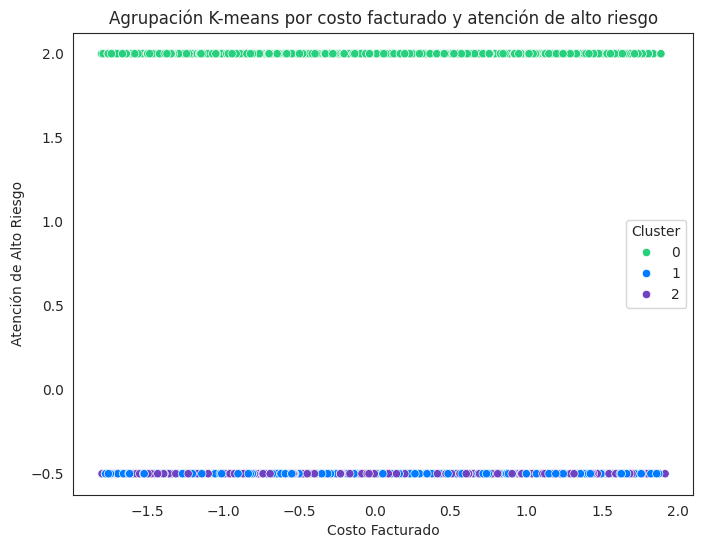

In [28]:
# visualizar los clústeres
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_scaled_kmeans,
    x=_Billing_Amount_Normalized_,
    y=_High_Risk_Combo_,
    hue="Cluster",
    palette=_paleta_secundaria)

# titulos
plt.title("Agrupación K-means por costo facturado y atención de alto riesgo")
plt.xlabel("Costo Facturado")
plt.ylabel("Atención de Alto Riesgo")
plt.legend(title="Cluster")
plt.show()

El gráfico muestra el resultado de la agrupación K-means básica utilizando solo las variables estandarizadas:
- Costo facturado en el eje x
- Nivel de Alto Riesgo en el eje Y

**Interpretación de la agrupación K-means**

- Los puntos de datos se han dividido forzosamente en dos líneas horizontales, creando tres clústeres.
- El Clúster 0 ocupa completamente el sector de nivel de alto riesgo/costo.
- Y los clústeres 1 y 2 se dividen en niveles de menor riesgo/costo de atención.

Esta agrupación resulta ser débil porque podria estar ignorando otras variables para el Costo Facturado, por lo que se confirma la necesidad de usar PCA, ya que el modelo necesita más dimensiones para encontrar perfiles de riesgo más significativos.

## 🔅 Reducción dimensional - PCA

Debido a que la agrupación K-means resulto ser muy debil para llegar a una conclusión, esto obliga la necesidad del cálculo mediante PCA.

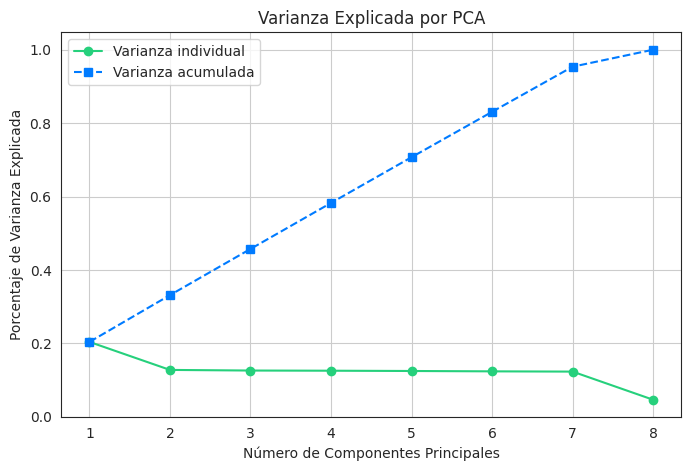

In [29]:
# aplicando PCA
# PCA sin reducir componentes aún (para ver varianza explicada)
pca = PCA()
pca.fit(X_scaled)

# varianza explicada por cada componente
varianza = pca.explained_variance_ratio_
componentes = np.arange(1, len(varianza)+1)

# visualización de la varianza explicada
plt.figure(figsize=(8, 5))

# Varianza individual
plt.plot(componentes,
varianza,
marker='o',
linestyle='-',
label='Varianza individual',
color=_color_tecmi_light)

# Varianza acumulada
plt.plot(componentes,
np.cumsum(varianza),
marker='s',
linestyle='--',
label='Varianza acumulada',
color=_color_primary)

plt.xlabel('Número de Componentes Principales')
plt.ylabel('Porcentaje de Varianza Explicada')
plt.title('Varianza Explicada por PCA')
plt.grid(True)
plt.legend()
plt.show()


A continuación, se aplica PCA solo con 2 componentes teniendo en cuenta la varianza explicada en el punto anterior.

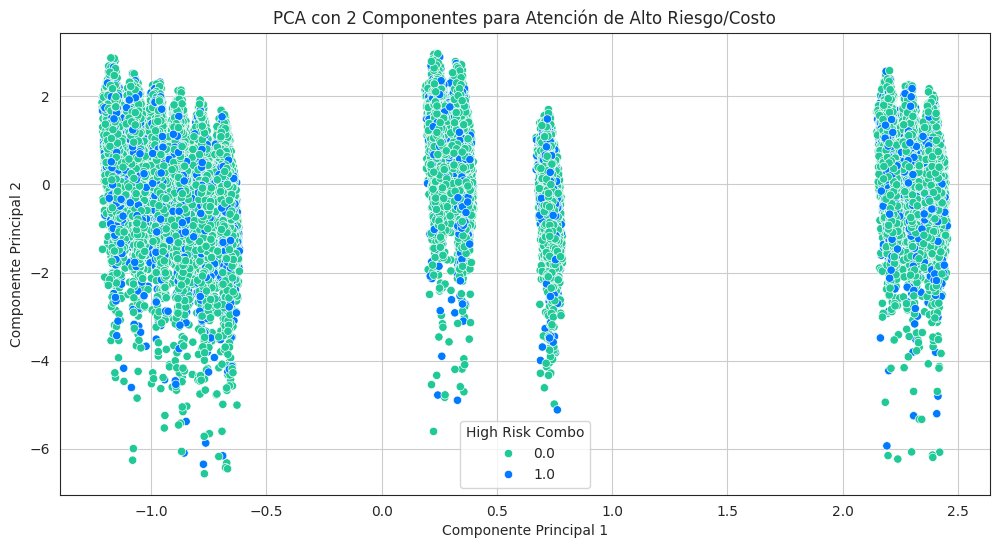

In [30]:
# aplicar PCA con dos componentes
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# nuevo DataFrame para visualizar
df_pca_1 = pd.DataFrame(data=X_pca, columns=["PC1", "PC2"])
df_pca_1[_High_Risk_Combo_] = df_limpio[_High_Risk_Combo_]

# visualización
plt.figure(figsize=(12,6))
sns.scatterplot(
    data=df_pca_1,
    x="PC1",
    y="PC2",
    hue=_High_Risk_Combo_,
    palette=[_color_teal, _color_primary])

# titulos
plt.title("PCA con 2 Componentes para Atención de Alto Riesgo/Costo")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.grid(True)
plt.legend(title=_High_Risk_Combo_)
plt.show()



El resultado del análisis con PCA muestra la distribución de los pacientes en el nuevo espacio de dos dimensiones, el PC1 y el PC2. Estos espacios fueron coloreados según la variable High Risk Combo para un mayor entendimiento de la distribución de pacientes.

**Interpretación de la Visualización PCA**
- Los datos se distribuyen en cuatro nubes verticales, confirmando que las variables criticas como la edad y el costo tienen estructuras o grupos muy definidos que el PCA está capturando en los dos primeras componentes.

- Se observa que la distribución del PC1 se extiende a lo largo del eje X, lo que sugiere que la PC1 es la componente más importante para diferenciar a los pacientes.

- Los puntos de color azul, que representan la combinación de alto riesgo están presentes en todos los grupos, y, si bien es capturada por las componentes principales, se entiende que no es la única fuerza impulsora que define a los mismos.

**Conclusión**

Este gráfico demuestra que la estrategia PCA fue exitosa para lograr separar visualmente a los pacientes en distintos grupos de comportamiento.

Sin embargo, se deduce que debemos aplicar un agrupamiento a cada nuevo espacio mediante K-means, para lograr perfilar de mejor manera a los segmentos de riesgo.

# 🛂 Análisis final multivariado

En este análisis final se combina PCA + K-means para lograr encontrar una mejor segmentación de los pacientes y su comportamiento.

En los puntos anteriores se observó que:
- K-means por separado se comporta débil al usar 8 variables.
- Por otro lado, PCA por separado solo reduce dimensiones, pero no segmenta.

En cambio, en esta propuesta, se ejecuta la combinación de K-means aplicado a las PC1 y PC2 para obtener clústeres significativos.

## Aplicación de PCA

Aplicaremos PCA para reducir de 8 variables a 2 o 3 componentes principales.

In [31]:
# PCA sin componentes iniciales para evaluar la varianza
pca = PCA()
principal_components = pca.fit_transform(X_scaled)

# varianza explicada por cada componente
varianza = pca.explained_variance_ratio_
componentes = np.arange(1, len(varianza)+1)

# datos de varianza
varianza_explicada = pca.explained_variance_ratio_
print("Varianza explicada por componente:")
for i, var in enumerate(varianza_explicada):
    print(f"PC{i+1}: {var*100:.2f}%")

Varianza explicada por componente:
PC1: 20.38%
PC2: 12.75%
PC3: 12.58%
PC4: 12.54%
PC5: 12.46%
PC6: 12.36%
PC7: 12.29%
PC8: 4.63%


In [32]:
# definimos el numero de componentes ideal
PCA_Components = 2

**Interpretación de la varianza explicada**

Dato que el PC1 explica el 20.38% y el PC2 explica el 12.75%, entonces el 33% de la información total se captura en solo dos variables. Esto justifica la reducción de la dimensionalidad de 8 variables a solo 2, simplificando el análisis de riesgo.

In [33]:
# PCA Final con solo 2 componentes principales
pca_final = PCA(n_components=PCA_Components)
X_pca = pca_final.fit_transform(X_scaled)
df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
df_limpio_pca = df_scaled.reset_index(drop=True).join(df_pca)

df_limpio_pca.head()

,Age,Duration of Stay (Days),Billing Amount (Normalized),Gender (Encoded),Medical Condition (Encoded),Frequency of Visit,High Risk Medication,High Risk Combo,PC1,PC2
0,-1.098521,-1.558386,-0.475238,0.99907,-0.291499,-0.500727,-0.816701,-0.500593,-0.926386,-0.983611
1,0.534104,-1.096574,0.567842,0.99907,-1.461997,-0.500727,-0.816701,-0.500593,-1.156613,0.270301
2,1.248378,-0.057496,0.166593,-1.00093,1.464248,-0.500727,-0.816701,-0.500593,-0.703147,0.163681
3,-1.200560,1.674300,0.868798,-1.00093,0.293750,-0.500727,-0.816701,-0.500593,-0.875126,0.023010
4,-0.435267,0.519769,-0.800990,-1.00093,-0.291499,-0.005321,1.224438,1.997633,2.212128,0.570781


### Determinación del K Óptimo

De acuerdo con Analytics Lane (2023): *El método del codo es una técnica que se emplea para determinar el número óptimo de clústeres para el algoritmo de K-means.*

Usaremos el método del codo para encontrar el número ideal de clústeres para K-means. La idea es encontrar el punto donde se produce un cambio brusco en la inercia del del cluster, para así, seleccionar el número ideal.

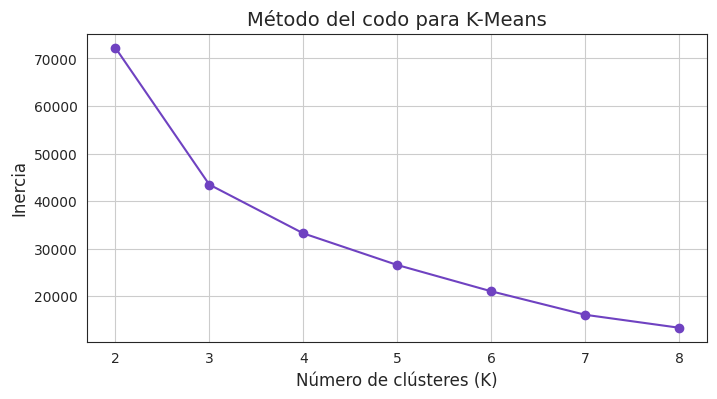

In [34]:
# método del codo para encontrar K óptimo
inercia = []
rango_k = range(2, 9)

for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca)
    inercia.append(kmeans.inertia_)

# grafica
plt.figure(figsize=(8, 4))
plt.plot(
    rango_k,
    inercia,
    marker='o',
    color=_color_purple)

# titulos
plt.title('Método del codo para K-Means', fontsize=14)
plt.xlabel('Número de clústeres (K)', fontsize=12)
plt.ylabel('Inercia', fontsize=12)
plt.grid(True)
plt.show()

In [35]:
# definiendo codo en K=5
K_optimo = 5

### Aplicación de K-means y perfilado de clústeres

Aplicamos K-means con el K óptimo y analizamos cómo se comportan las variables originales dentro de cada clúster.

In [36]:
# Aplicar K-means con K óptimo
kmeans = KMeans(n_clusters=K_optimo, random_state=42, n_init=10)
df_limpio_pca['Cluster'] = kmeans.fit_predict(X_pca)


# incluyendo los resultados del clustering con las variables originales estandarizadas
df_profiling = df_limpio.reset_index(drop=True).join(df_pca)
df_profiling['Cluster'] = df_limpio_pca['Cluster']

# incluyendo las medias de las variables originales para perfilar cada clúster
perfiles_cluster = df_profiling.groupby('Cluster')[columnas_modelo].mean()
perfiles_cluster = perfiles_cluster.reset_index()

print("\nPerfiles de Riesgo (Medias por Clúster):")
perfiles_cluster.head()


Perfiles de Riesgo (Medias por Clúster):


,Cluster,Age,Duration of Stay (Days),Billing Amount (Normalized),Gender (Encoded),Medical Condition (Encoded),Frequency of Visit,High Risk Medication,High Risk Combo
0,0,36.861658,9.323834,0.594342,0.529404,3.666969,3.694171,0.264896,0.006088
1,1,54.498490,16.947333,0.456835,0.489545,1.645421,1.646539,1.000000,0.000000
2,2,51.395723,15.468287,0.481904,0.504935,2.991409,1.943338,1.000000,1.000000
3,3,48.193245,14.039177,0.513245,0.509103,2.687166,1.848955,0.000836,0.000000
4,4,63.514156,20.433924,0.399504,0.474040,1.665298,1.455906,0.000000,0.000000


### Mapeo de nombres de clusters

In [37]:
# se definen los nombres de riesgo a los índices de clúster
# el mapeo coincide de acuerdo a los perfiles definimos en el paso anterior
# los nombre de cluster fueron definidos a partir de las variables involucradas en cada uno
mapeo_riesgo = {
    0: 'Riesgo Crónico Medio (Jóvenes Frecuentes)',
    1: 'Riesgo Bajo/Agudo',
    2: 'Riesgo Alto/Crónico',
    3: 'Riesgo Bajo/Población General',
    4: 'Riesgo Latente/Estancia Larga'
}

# mapeo para crear la nueva columna 'Risk Profile' en el dataset de clusters y pca
df_limpio_pca.loc[:, 'Risk Profile'] = df_limpio_pca['Cluster'].map(mapeo_riesgo)

# mapeo en los perfiles de riesgo
perfiles_cluster.loc[:, 'Risk Profile'] = perfiles_cluster['Cluster'].map(mapeo_riesgo)

print("\033[1m --- Perfiles de riesgo con las medias de variables originales por clúster --- \033[0m")
print("-" * 80)
perfiles_cluster


 --- Perfiles de riesgo con las medias de variables originales por clúster --- 
--------------------------------------------------------------------------------


,Cluster,Age,Duration of Stay (Days),Billing Amount (Normalized),Gender (Encoded),Medical Condition (Encoded),Frequency of Visit,High Risk Medication,High Risk Combo,Risk Profile
0,0,36.861658,9.323834,0.594342,0.529404,3.666969,3.694171,0.264896,0.006088,Riesgo Crónico Medio (Jóvenes Frecuentes)
1,1,54.498490,16.947333,0.456835,0.489545,1.645421,1.646539,1.000000,0.000000,Riesgo Bajo/Agudo
2,2,51.395723,15.468287,0.481904,0.504935,2.991409,1.943338,1.000000,1.000000,Riesgo Alto/Crónico
3,3,48.193245,14.039177,0.513245,0.509103,2.687166,1.848955,0.000836,0.000000,Riesgo Bajo/Población General
4,4,63.514156,20.433924,0.399504,0.474040,1.665298,1.455906,0.000000,0.000000,Riesgo Latente/Estancia Larga


### 📑 Interpretación de los resultados

El Análisis de grupos mediante K-means y PCA revela la existencia de cinco perfiles de riesgo bien diferenciados, permitiendo a la aseguradora pasar de la gestión general a la estrategia segmentada de los pacientes.

**Clúster 2: Riesgo Alto/Crónica**

Este es el único clúster donde el indicador de Alto Riesgo Combo es 1.000, lo que significa que todos los pacientes de este grupo tienen una condición crónica y reciben medicación de alto riesgo. Su facturación es moderada, pero su edad media es de 51 años y su estancia media en el hospital es de 15 días.

**Clúster 0: Riesgo Crónico Medio**

Es el grupo más joven, con un promedio de 36 años, tiene la mayor frecuencia de visita y la facturación más alta.

**Clúster 4: Riesgo Latente/Estancia Larga**

El grupo de mayor edad, con un promedio de 63 años y con la estancia más larga en el hospital, con un promedio de 20.43 días. A pesar de esto, su facturación media es baja.

**Clústeres 1 y 3: Riesgo Bajo/Población General**

Representan la población estándar de la aseguradora, con riesgos bajos y patrones de uso promedio.

In [38]:
comparacion = pd.crosstab(df_limpio_pca['High Risk Combo'], df_limpio_pca['Cluster'])
comparacion

Cluster,0,1,2,3,4
High Risk Combo,,,,,
-0.500593,7673,8943,0,15545,11691
1.997633,47,0,10942,0,0


### 💹 Visualización del Clustering mediante K-means y PCA

Originalmente se habia planteado el uso de un K-optimo de cuatro, pero se llego a la conclusión de añadir un cluster más para mejorar los perfiles visuales.

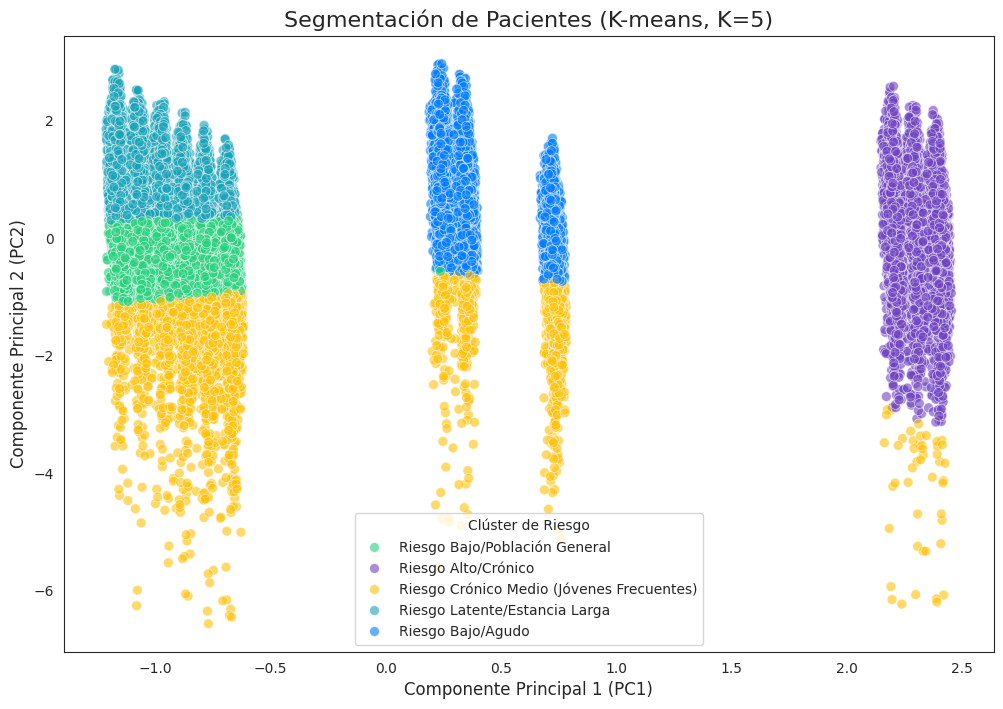

In [39]:
# visualización de los clusteres
plt.figure(figsize=(12, 8))

# visualizando los clusteres usando PC1 y PC2
sns.scatterplot(
        x='PC1',
        y='PC2',
        hue='Risk Profile',
        data=df_limpio_pca,
        palette=_paleta_tecmi,
        s=50,
        alpha=0.6)

# Títulos
plt.title(f'Segmentación de Pacientes (K-means, K={K_optimo})', fontsize=16)
plt.xlabel('Componente Principal 1 (PC1)', fontsize=12)
plt.ylabel('Componente Principal 2 (PC2)', fontsize=12)
plt.legend(title='Clúster de Riesgo')
plt.show()

Como se puede observar, el gráfico muestra claramente el resultado de la segmentación de pacientes mediante la combinación de PCA y K-means.

Esta estrategia ha sido exitosa, ya que ha logrado agrupar a la población de pacientes en perfiles de riesgo visualmente distintos.

**Conclusión**

Mediante los análisis previos, se han perfilado 5 grupos con base en las medias de las variables originales. De esta manera se podrían dedicar esfuerzos a grupos específicos, por ejemplo, debido a que el Clúster 2 tiene la media más alta de High Risk Combo y Billing Amount, la empresa de seguros podría enfocar sus programas de prevención de enfermedades crónicas en estos pacientes para mitigar los costos futuros.

# 🕑 Modelado de series temporales

Procedamos con la fase final de la Evidencia Final: el modelado de series temporales.

Para aplicar modelos como ARIMA o SARIMA, necesitamos una variable clave indexada por tiempo. En nuestro dataset de salud, la métrica más valiosa para el pronóstico es la suma de los gastos médicos facturados indexada por mes.

Dado que el análisis exploratorio mostró que las admisiones por mes son uniformes, vamos a generar una serie temporal para la carga de costos por mes.

## Preparación de la Serie Temporal

Primero, necesitamos agregar el costo facturado por fecha mensual.

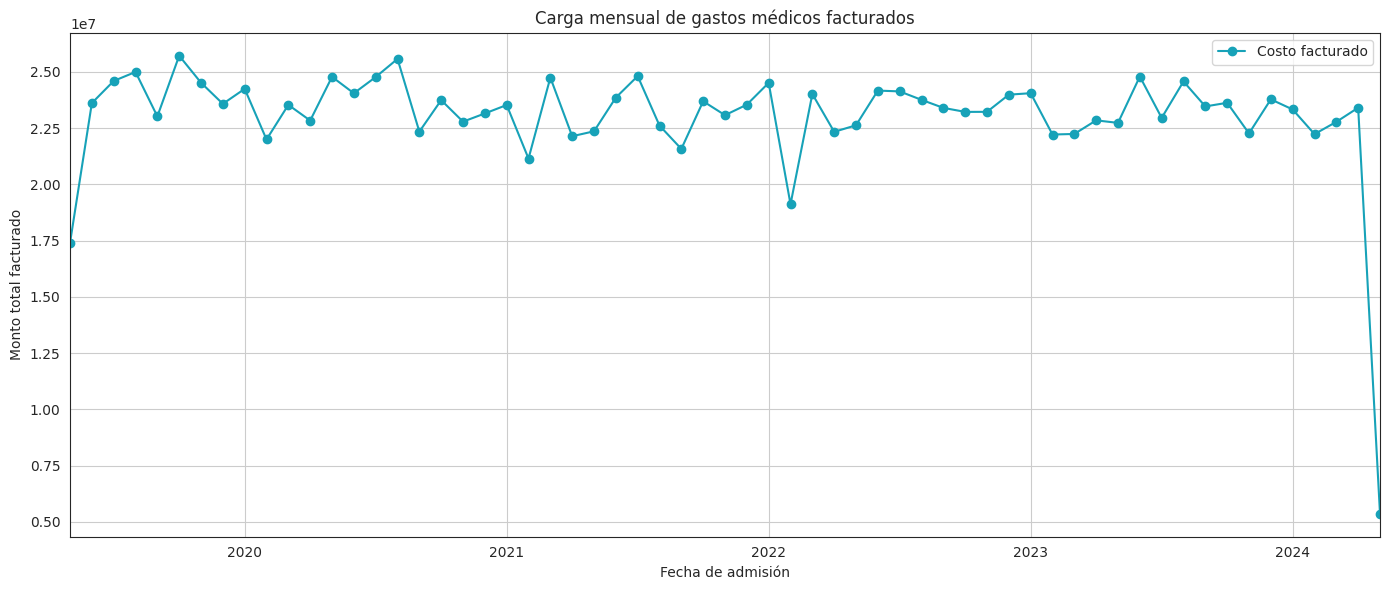

In [40]:
# Billing Amount por Date of Admission mensual.
# nos aseguramos que las fechas sean el índice para la serie temporal
df_ts = df_profiling.set_index(_Date_Admission_).copy()

# agregamos el monto facturado por mes / convertima a inicio de mes con 'MS'
serie_mensual = df_ts['Billing Amount'].resample('MS').sum()

# visualizar la serie temporal resultante
plt.figure(figsize=(14, 6))

serie_mensual.plot(
    label="Costo facturado",
    color=_color_info,
    marker='o')

# titulos
plt.title('Carga mensual de gastos médicos facturados')
plt.xlabel('Fecha de admisión')
plt.ylabel('Monto total facturado')
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()


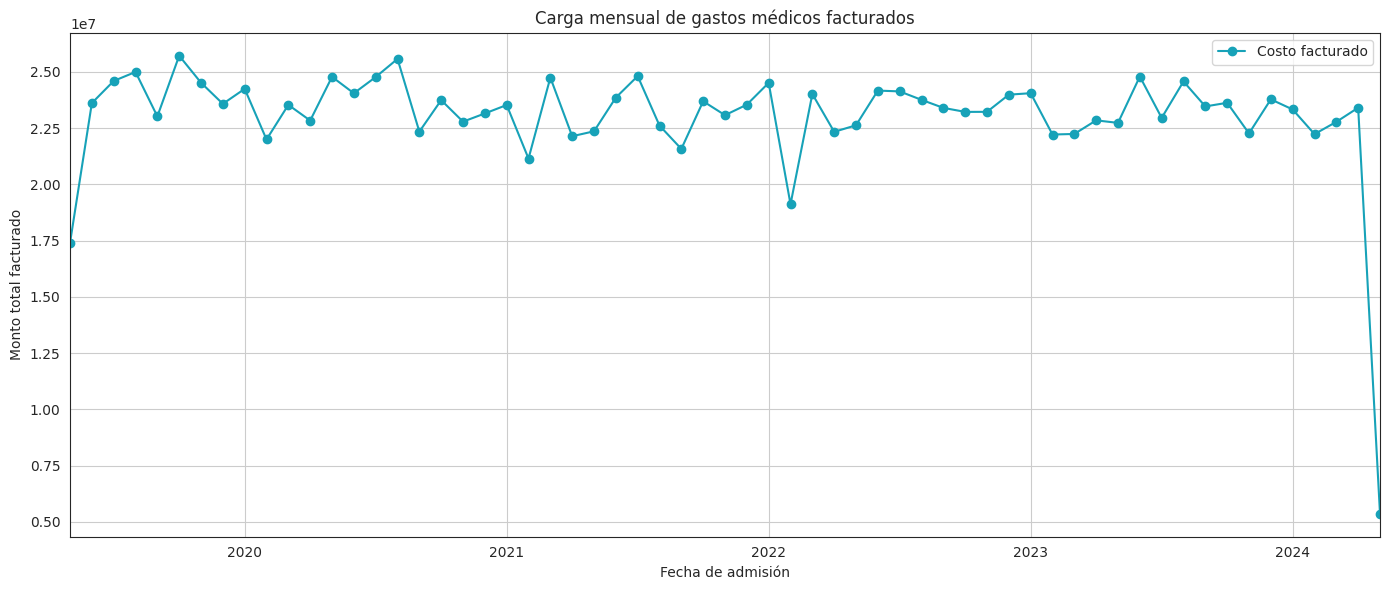

In [41]:
# Billing Amount por Date of Admission mensual.
# nos aseguramos que las fechas sean el índice para la serie temporal
df_ts = df_profiling.set_index(_Date_Admission_).copy()

# agregamos el monto facturado por mes / convertima a inicio de mes con 'MS'
serie_mensual = df_ts['Billing Amount'].resample('MS').sum()

# visualizar la serie temporal resultante
plt.figure(figsize=(14, 6))

serie_mensual.plot(
    label="Costo facturado",
    color=_color_info,
    marker='o')

# titulos
plt.title('Carga mensual de gastos médicos facturados')
plt.xlabel('Fecha de admisión')
plt.ylabel('Monto total facturado')
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()


El gráfico de la serie temporal "Carga mensual de gastos médicos facturados" revela un patrón dominado por la volatidad y sin una tendencia positiva para la empresa.

- A primera vista se observa que la serie temporal no muestra una tendencia de crecimiento o decrecimiento a largo plazo. De manera similar, no hay un patrón de estacionalidad claro. Esto refuerza los hallazgos del EDA.


## Descomposición de la Serie Temporal

La descomposición nos ayuda a identificar si existen tendencia o estacionalidad en los gastos.

In [42]:
# Paso 2: Descomposición aditiva asumiendo estacionalidad anual:
descomposicion = seasonal_decompose(serie_mensual, model='additive', period=12)

## 📉 Tendencia

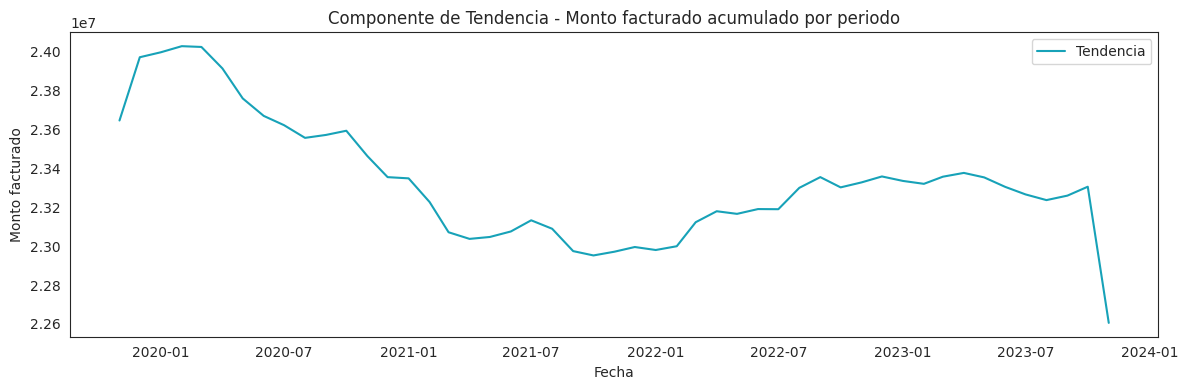

In [43]:
# Paso 3: Tendencia:
plt.figure(figsize=(12, 4))
plt.plot(
    descomposicion.trend,
    label="Tendencia",
    color=_color_info
    )
# titulos
plt.title("Componente de Tendencia - Monto facturado acumulado por periodo")
plt.xlabel("Fecha")
plt.ylabel("Monto facturado")
plt.legend()
plt.tight_layout()
plt.show()

**Análisis de la Componente de Tendencia**

El gráfico del Componente de Tendencia suaviza el ruido mensual para revelar el movimiento a largo plazo de los montos facturados por los pacientes.

- Se puede apreciar una tendencia a largo plazo descendente y algo volátil.
- La tendencia muestra un decremento inicial desde finales de 2019 hasta principios de 2021.
- Sigue un periodo de estabilización de 2021 a 2022.
- Finalmente, la tendencia muestra un ligero repunte a mediados de 2022 y 2023, antes de caer drásticamente al final de la serie.

**Implicación Estratégica**

La principal conclusión es que el monto facturado promedio de la compañía no está creciendo de manera sostenida. Definitivamente no existe una tendencia positiva que sea clara.

**Impacto en el Modelado**

La volatilidad de esta tendencia hace que sea muy difícil de pronosticar con un modelo simple como ARIMA. Esto confirma que el modelo de series temporales no es la mejor herramienta para el pronóstico de gastos en este dataset; **la segmentación de riesgo es la mejor estrategia**.

## 📉 Estacionalidad

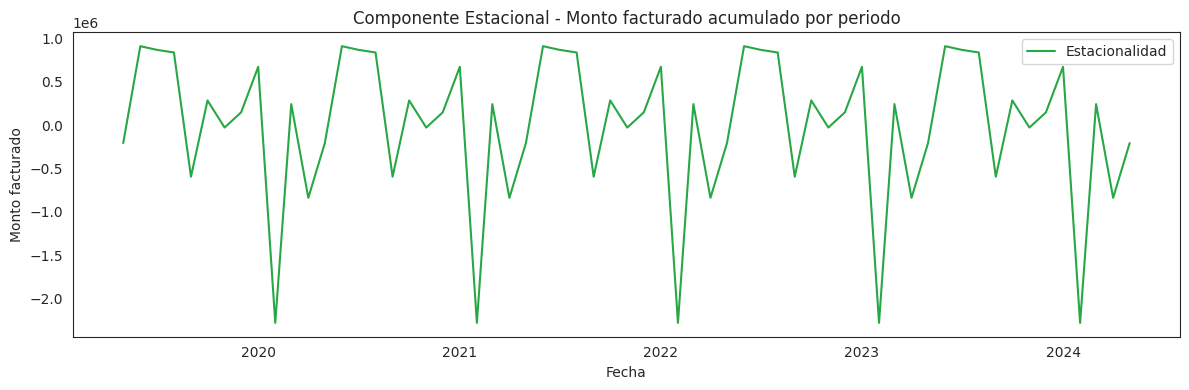

In [44]:
# Paso 4: Estacionalidad:
plt.figure(figsize=(12, 4))
plt.plot(
    descomposicion.seasonal,
    label="Estacionalidad",
    color=_color_success)

# titulos
plt.title("Componente Estacional - Monto facturado acumulado por periodo")
plt.xlabel("Fecha")
plt.ylabel("Monto facturado")
plt.legend()
plt.tight_layout()
plt.show()

**Análisis de la Componente Estacional**

El gráfico del Componente Estacional muestra la fluctuación del gasto médico que se repite anualmente, después de eliminar la tendencia y el ruido, sin embargo en el gráfico podemos observar que:

- Aunque los ciclos suben y bajan de manera recurrente, estos no se alinean correctamente en esta fase de tiempo.

- El componente estacional se aprecia muy volátil, con cambios abruptos de un mes a otro. Esto indica que los factores que impulsan las variaciones mensuales son muy fuertes, pero no son puramente estacionales.

**Conclusión Estratégica**

Este hallazgo confirma que la estacionalidad no es el principal motor de los montos facturados. La falta de un patrón de 12 meses predecible hace que un modelo SARIMA resulte ineficaz.
La volatidad observada en la serie de tiempo se debe, en gran medida, a eventos aleatorios y fluctuaciones irregulares a largo plazo.

Esto refuerza nuestra decisión de **centrar la estrategia de predicción en el Análisis Multivariado y la segmentación de riesgo.**

## 📉 Residuo

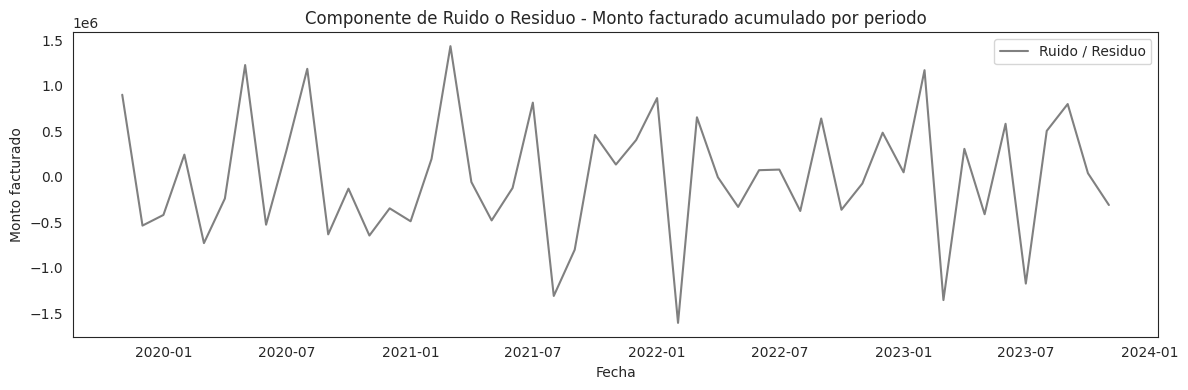

In [45]:
# Paso 5. Residuo:
plt.figure(figsize=(12, 4))
plt.plot(
    descomposicion.resid,
    label="Ruido / Residuo",
    color='gray')

# titulos
plt.title("Componente de Ruido o Residuo - Monto facturado acumulado por periodo")
plt.xlabel("Fecha")
plt.ylabel("Monto facturado")
plt.legend()
plt.tight_layout()
plt.show()

**Análisis del Ruido en Vista de Línea**

- La línea temporal de ruido muestra picos y valles muy abruptos de un mes a otro, y ocurren cambios violentos entre valores positivos y negativos. Esta alta volatilidad confirma que el componente de error es sumamente fuerte.
- El ruido graficado no tiene estructura y, por lo tanto,  no es predecible. Por ejemplo, la línea que vemos es altamente irregular, cruzando la línea cero constantemente, indicando que el valor del error de un mes no depende del valor del error del mes anterior.

### Gráfica de ruido auxiliar

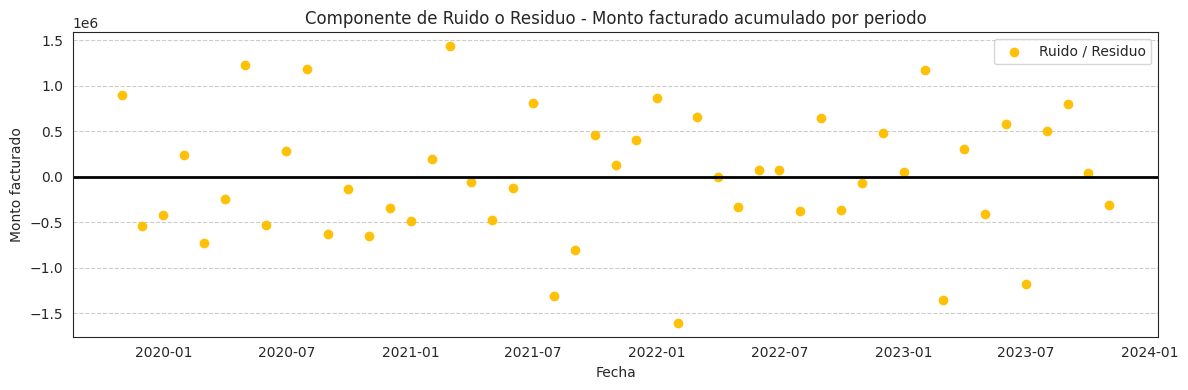

In [46]:
# Paso 5. Residuo:
plt.figure(figsize=(12, 4))

# grafico de dispersión del residuo a lo largo del tiempo
plt.scatter(
    descomposicion.resid.index,
    descomposicion.resid.values,
    label="Ruido / Residuo",
    color=_color_warning)

# línea de referencia horizontal en Y=0
plt.axhline(0, color='black', linestyle='-', linewidth=2)


# titulos
plt.title("Componente de Ruido o Residuo - Monto facturado acumulado por periodo")
plt.xlabel("Fecha")
plt.ylabel("Monto facturado")
plt.legend()
plt.tight_layout()
plt.grid(True, axis='y', linestyle='--')
plt.show()


**Análisis de la Componente de Ruido**

El gráfico muestra que los puntos de datos se dispersan de manera irregular alrededor de la línea cero. No se observa un patrón comprensible; no hay ciclos repetitivos, ni agrupaciones claras de puntos por encima o por debajo de la línea cero durante períodos largos.

Debido a este patrón errático y la falta de rachas significativas se confirma que el ruido es meramente aleatorio.

La gráfica de ruido demuestra que el componente de ruido es el elemento dominante en la serie. Esto significa que la mayor parte de la variabilidad del gasto mensual facturado es impredecible a través de modelos de tiempo.

**Conclusión Estratégica**

Dado que la mayor parte de la variabilidad del gasto es ruido, se deduce que el costo está siendo impulsado por eventos impredecibles que no tienen relación con la fecha, **lo que nos obliga a depender completamente de los perfiles de riesgo multivariados K-means que han demostrado ser una mejor estrategia de predicción para este dataset.**

# 🧭 Aplicación y Evaluación del Modelo ARIMA

Dado que el análisis previo no mostró una estacionalidad fuerte, utilizaremos un modelo ARIMA simple para pronosticar los gastos. Para ello, se usaran los últimos meses de datos como conjunto de prueba para evaluar el rendimiento del modelo.


Métricas de desempeño del Modelo ARIMA:
Error Absoluto Medio (MAE): $3,476,783.32
Raíz del Error Cuadrático Medio (RMSE): $7,060,066.08
Error Porcentual Absoluto Medio (MAPE): 52.99%


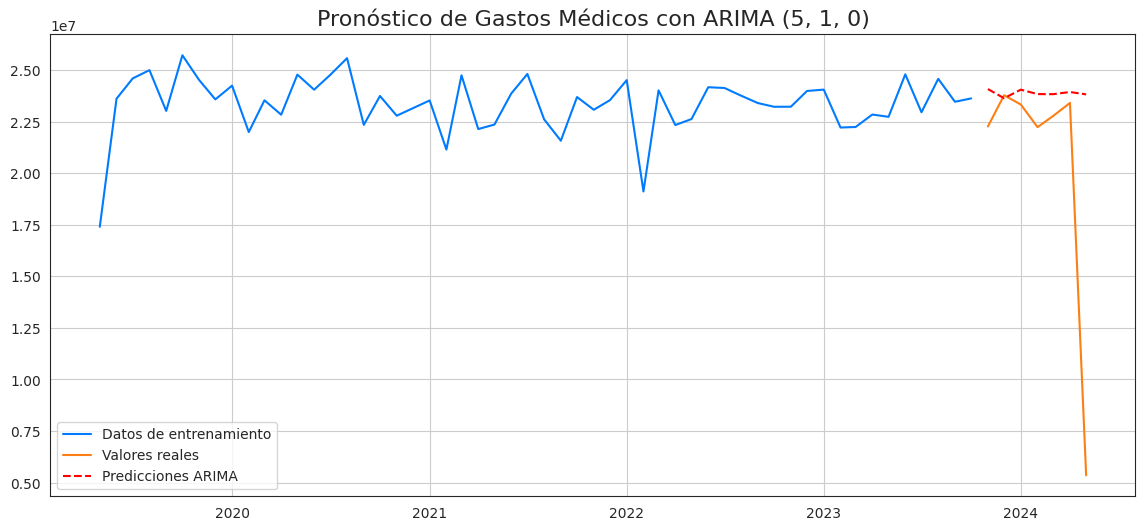

In [47]:
# 1. dividimos la serie menusal de datos en entrenamiento = 90% y prueba = 10%
size = int(len(serie_mensual) * 0.9)
train, test = serie_mensual[:size], serie_mensual[size:]

# 2. definimos el orden ARIMA con valores por defecto (p=5, d=1, q=0)
# p=5 (Retrasos AutoRegresivos), d=1 (Diferenciación para estacionariedad), q=0 (Media Móvil)
order = (5, 1, 0)

# 3. entrenamiento del modelo ARIMA
modelo = ARIMA(train, order=order)
modelo_fit = modelo.fit()

# 4. se generan los pronósticos
# start y end definen el rango de la predicción (equivalente al set de prueba)
start_index = len(train)
end_index = len(serie_mensual) - 1
predictions = modelo_fit.predict(start=start_index, end=end_index, dynamic=False)

# 5. evaluamos el desempeño del modelo
mae = mean_absolute_error(test, predictions)
rmse = np.sqrt(mean_squared_error(test, predictions))
mape = np.mean(np.abs(predictions - test) / np.abs(test)) * 100

print("\nMétricas de desempeño del Modelo ARIMA:")
print(f"Error Absoluto Medio (MAE): ${mae:,.2f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): ${rmse:,.2f}")
print(f"Error Porcentual Absoluto Medio (MAPE): {mape:.2f}%")

# 6. visualizacion de la predicción
plt.figure(figsize=(14, 6))

# Datos de entrenamiento
plt.plot(
    train,
    label='Datos de entrenamiento',
    color=_color_primary)

# Valores Reales
plt.plot(test, label='Valores reales', color=_color_orange)

# Predicciones ARIMA
plt.plot(predictions, label='Predicciones ARIMA', color='red', linestyle='--')

# titulos
plt.title(f'Pronóstico de Gastos Médicos con ARIMA {order}', fontsize=16)
plt.legend()
plt.grid(True)
plt.show()

El gráfico de pronóstico es la prueba visual más contundente de la ineficacia del modelo ARIMA para este Dataset.

**Análisis Visual del Pronóstico ARIMA**
- La línea azul de Datos de entrenamiento, muestra una alta volatilidad, pero la línea roja, que corresponde a las Predicciones ARIMA, se limita a seguir la media histórica de manera plana. Esto confirma que el modelo no detectó ni la tendencia sutil ni los picos y valles de la serie.

- La línea naranja, que son los valores reales, muestra una caída drástica y un pico de recuperación en los últimos puntos de la prueba. En contraste, la línea de predicción no solo falla en capturar esta volatilidad extrema, sino que predice un valor constante ligeramente superior al entrenamiento.

- El modelo ARIMA es incapaz de gestionar la volatilidad impulsada por el ruido de eventos únicos, como pudiese ocurrir en hospitalizaciones de emergencia de alto costo.

Finalmente, esta gráfica justifica la decisión de descartar el pronóstico basado en el tiempo y enfocar todos los recursos en la clasificación de riesgos del paciente, utilizando K-means y PCA.

**El cuándo ocurre el gasto es impredecible, pero el quién está en riesgo no lo es.**

## Interpretación y Hallazgos del Modelo

**Interpretación de la Métricas de desempeño del Modelo**

**Error Porcentual Absoluto Medio (MAPE): 53% 🚨**

Este valor es catastrófico para cualquier modelo de pronóstico financiero. Significa que, en promedio, la predicción del modelo se desvía del gasto real en un 53 por ciento. En términos de negocio, esto implica que si el modelo pronostica 10 millones en gastos, el costo real podría ser de tan solo 4.7 millones o hasta 15.3 millones. Este nivel de error hace que el pronóstico sea inútil para la planificación financiera y la gestión de reservas de la aseguradora.


**Error Absoluto Medio (MAE): mayor a 3 millones y Raíz del Error Cuadrático Medio (RMSE): 7 millones**

Estas métricas confirman la magnitud del error. El RMSE, en particular, indica que el error promedio de la predicción es de más de 7 millones. Y, dada la escala de la serie temporal, que oscilaba alrededor de 25 millones, un error de 7 millones es una desviación masiva.


El análisis ha demostrado:
- El día o mes en que ocurre el gasto es aleatorio.
- La variabilidad del gasto es explicada por las características intrínsecas del paciente, como bien lo explican los Clúster 2: Riesgo Alto/Crónico y Clúster 0: Jóvenes Frecuentes.

# 🕔 Modelato de serie temporal del Clúster 2: Riesgo Alto/Crónica

Debido a que el modelado de series temporales general para el dataset, resulto ser no muy optimo, he decidio realizar el modelado temporal unicamente para el Clúster 2: Riesgo Alto/Crónica

Con esta lógica, se analizará un subsegmento de alto riesgo, lo que podría revelar patrones que el conjunto de datos completo oculta. Si el clúster de alto riesgo tiene una tendencia de costos modelable, se podrían hacer predicciones precisas solo para ese grupo, lo cual es mucho más útil para la aseguradora.

In [48]:
# agrupando solo la informacion del cluster 2
data_cluster_2 = df_profiling.loc[df_profiling['Cluster'] == 2]
print("Datos de pacientes del Cluster = 2:")
data_cluster_2.head()

Datos de pacientes del Cluster = 2:


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,...,Duration of Stay (Days),Billing Amount (Normalized),Gender (Encoded),Medical Condition (Encoded),Frequency of Visit,High Risk Medication,High Risk Combo,PC1,PC2,Cluster
4,adrienne bell,43.0,Female,AB+,Cancer,2022-09-19,kathleen hanna,white-white,Aetna,14238.317814,...,20,0.269720,0,2,2,1,1,2.212128,0.570781,2
11,aaron martinez,38.0,Female,A-,Hypertension,2023-08-13,douglas mayo,lyons-blair,Medicare,7999.586880,...,23,0.151461,0,4,4,1,1,2.410432,-0.203876,2
12,connor hansen,75.0,Female,A+,Diabetes,2019-12-12,kenneth fletcher,"powers miller, and flores",Cigna,43282.283358,...,16,0.820264,0,3,1,1,1,2.261802,0.579020,2
26,mr. kenneth moore,34.0,Female,A+,Diabetes,2022-06-21,james ellis,serrano-dixon,UnitedHealthcare,18834.801341,...,9,0.356849,0,3,1,1,1,2.316635,-0.402850,2
27,mary hunter,38.0,Female,O-,Hypertension,2021-01-03,jared bruce jr.,gardner-miller,Cigna,32643.299353,...,13,0.618596,0,4,1,1,1,2.395776,-0.595221,2


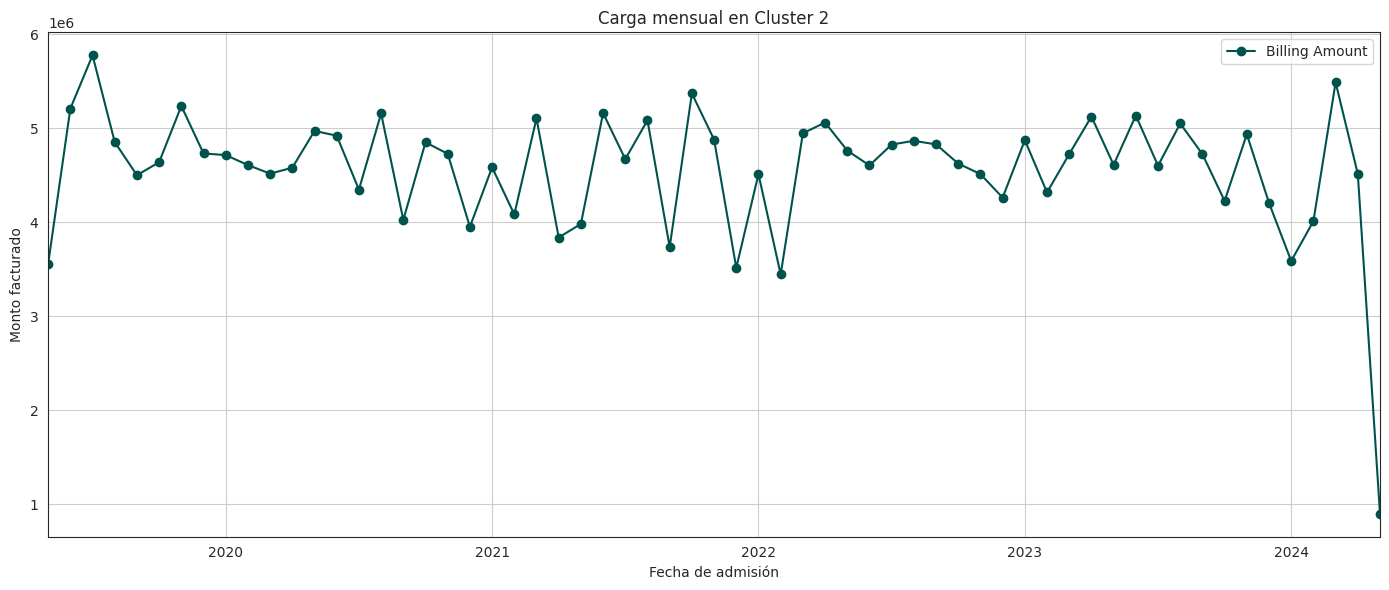

In [49]:
# Billing Amount por Date of Admission mensual.
# nos aseguramos que las fechas sean el índice para la serie temporal
df_ts2 = data_cluster_2.set_index(_Date_Admission_).copy()

# agregamos el monto facturado por mes / convertima a inicio de mes con 'MS'
serie_mensual_cl2 = df_ts2['Billing Amount'].resample('MS').sum()

# visualizar la serie temporal resultante
plt.figure(figsize=(14, 6))

serie_mensual_cl2.plot(
    label="Billing Amount",
    color=_color_tecmi_dark,
    marker='o')

# titulos
plt.title('Carga mensual en Cluster 2')
plt.xlabel('Fecha de admisión')
plt.ylabel('Monto facturado')
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

La gráfica muestra que incluso después de aislar el segmento de riesgo más crítico y homogéneo del dataset, el monto facturado sigue siendo impredecible en el tiempo.

Esto confirma que los modelos de series temporales (ARIMA/SARIMA) son inútiles para este dataset y que la variabilidad mensual se debe a la naturaleza aleatoria del evento médico y no a factores de tiempo o demográficos.

## Descomposición de la Serie Temporal para el Clúster 2

In [50]:
# Paso 2: Descomposición aditiva asumiendo estacionalidad anual:
descomposicion_cluster2 = seasonal_decompose(serie_mensual_cl2, model='additive', period=12)

## 📉 Tendencia del Clúster 2

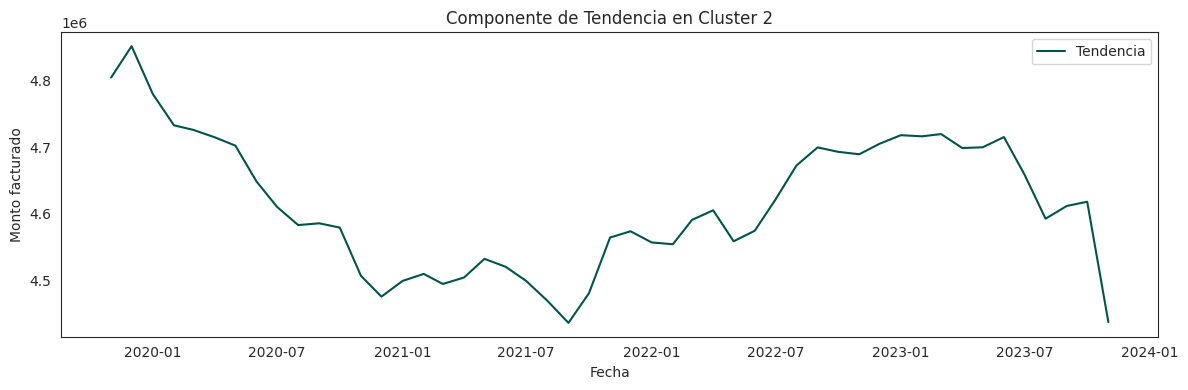

In [51]:
# Paso 3: Tendencia:
plt.figure(figsize=(12, 4))
plt.plot(
    descomposicion_cluster2.trend,
    label="Tendencia",
    color=_color_tecmi_dark
    )
# titulos
plt.title("Componente de Tendencia en Cluster 2")
plt.xlabel("Fecha")
plt.ylabel("Monto facturado")
plt.legend()
plt.tight_layout()
plt.show()

El análisis de la tendencia del Clúster 2 confirma que la variabilidad en los costos no es simple y refuerza la necesidad de utilizar la segmentación mediante K-means como la herramienta principal para la gestión de riesgos.

## 📉 Estacionalidad del Clúster 2

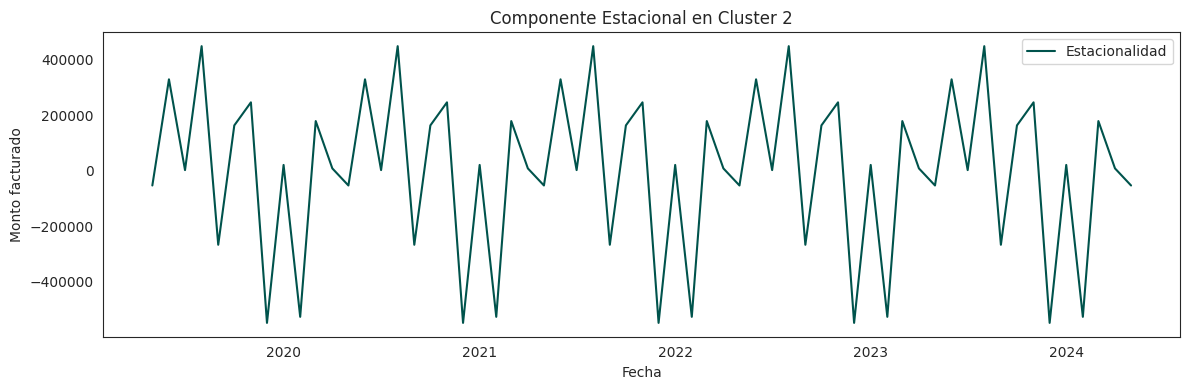

In [52]:
# Paso 4: Estacionalidad:
plt.figure(figsize=(12, 4))
plt.plot(
    descomposicion_cluster2.seasonal,
    label="Estacionalidad",
    color=_color_tecmi_dark)

# titulos
plt.title("Componente Estacional en Cluster 2")
plt.xlabel("Fecha")
plt.ylabel("Monto facturado")
plt.legend()
plt.tight_layout()
plt.show()

La gráfica muestra que, incluso a pesar de aislar el segmento de mayor riesgo, la estacionalidad sigue siendo demasiado ruidosa para ser modelada con precisión por un SARIMA.

## 📉 Residuo del Clúster 2

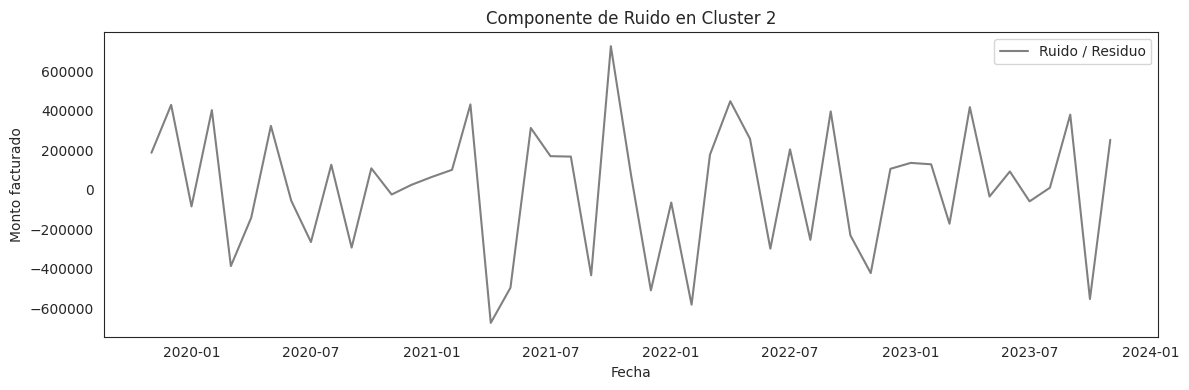

In [53]:
# Paso 5. Residuo:
plt.figure(figsize=(12, 4))
plt.plot(
    descomposicion_cluster2.resid,
    label="Ruido / Residuo",
    color='gray')

# titulos
plt.title("Componente de Ruido en Cluster 2")
plt.xlabel("Fecha")
plt.ylabel("Monto facturado")
plt.legend()
plt.tight_layout()
plt.show()

Finalmente, dado que el residuo es esencialmente ruido blanco de alta amplitud, el modelo ARIMA no puede pronosticar este segmento con precisión.

**Definitivamente la estrategia de predicción para este Dataset debe depender por completo de la Clasificación de Riesgos de los nuevos pacientes, utilizando la combinación de K-means y PCA, y no del tiempo.**